Epoch 1/10


C:\Users\VEDANG\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3070 - loss: 2.6516 - val_accuracy: 0.5462 - val_loss: 1.6101
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6202 - loss: 1.4052 - val_accuracy: 0.6675 - val_loss: 1.2371
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6865 - loss: 1.1594 - val_accuracy: 0.7047 - val_loss: 1.0882
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7236 - loss: 1.0347 - val_accuracy: 0.7266 - val_loss: 1.0010
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7424 - loss: 0.9536 - val_accuracy: 0.7419 - val_loss: 0.9288
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7580 - loss: 0.8940 - val_accuracy: 0.7575 - val_loss: 0.8807
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7655 - loss: 0.8510 - val_accuracy: 0.7638 - val_loss: 0.8543
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7746 - loss: 0.8138 - val_accuracy: 0.7550 - val_

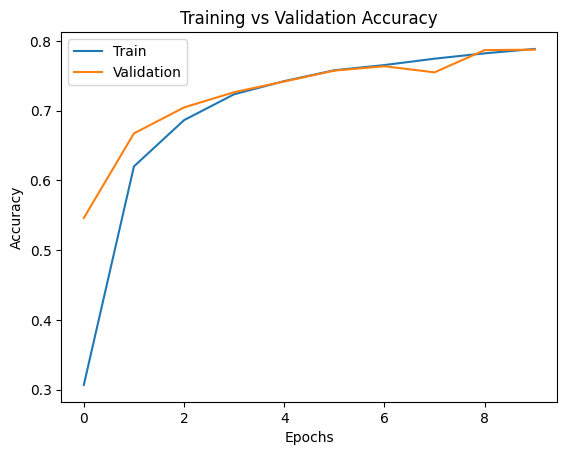

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("letter-recognition.data", header=None)

# Split
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# Encode labels
y = LabelEncoder().fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(16,)),
    Dense(26, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()